# Musterlösung 7

In [3]:
import numpy as np
from numpy.fft import fftfreq, fft, ifft
import matplotlib.pyplot as plt

# Aufgabe 1: Glätten mit gleitendem Mittelwert

Eine einfache Methode, um das Rauschen in Daten zu reduzieren, ist, den gleitenden Mittelwert (moving average) zu bilden. Das heisst, jeder Datenpunkt $x_i$ wird durch den Mittelwert der benachbarten Datenpunkte ersetzt:

$$\tilde{x}_i = \mathrm{mean}(\{x_{i-\Delta}, \dots, x_{i+\Delta}\}),$$

wobei $x_i$ die gemessenen und $\tilde{x}_i$ die geglätteten Datenpunkte sind.

## a)

Schreiben Sie eine Funktion, die ein gegebenes Datenarray auf diese Weise glättet. Als Argumente sollen die Datenpunkte und die Anzahl Indizes, über die gemittelt wird, übergeben werden.

Überlegen Sie sich, wie Sie die Randwerte behandeln möchten (also Indizes $i=0, \dots, \Delta$ und $i=N-1-\Delta,\dots,N-1$). Es gibt verschiedene Möglichkeiten, die alle ihre Berechtigung haben.

### Lösung

Bei den Randwerten gibt es das Problem, dass der Bereich, über den gemittelt wird, über die Grenzen des Arrays herausragt. Typischerweise wird auf eine der folgenden drei Arten damit umgegangen:

- Man fängt erst beim index $i = \Delta$ mit dem Mitteln an und hört bei $i=N-1-\Delta$ auf. Das resultierende Array mit den geglätteten  Daten ist dann um $2\Delta$ Einträge kürzer als die originalen Daten.
- Man wiederholt den ersten und letzten Wert über die Grenzen des Arrays hinaus. So kann ein geglättetes Datenarray mit der gleichen Länge wie das Originalarray erzeugt werden.
- Man hängt die beiden Enden des Datenarrays zusammen und erzeugt sozusagen periodische Randbedingungen. Auf diese Weise kann das geglättete Array wieder die gleiche Länge haben wie das ursprüngliche. Diese Methode ist vor allem bei periodischen Signalen sinnvoll.

Unten finden Sie eine Funktion, bei der alle drei Varianten implementiert sind, und mit dem Argument `edges` die gewünschte Methode gewählt werden kann. In vielen Fällen kann man sich von Anfang an für eine Methode entscheiden, und muss den Code nicht so allgemein halten.

Für den Rest der Musterlösung werden wir die Methode 'repeat' verwenden, also den ersten und letzten Datenpunkt wiederholen.

In [1]:
def moving_average(x, delta, edges='repeat'):
    '''Calculate moving average of data array x. Average goes from i-delta to i+delta for every i.
    The argument edges determines how the edge of the array is treated. Options are:
        'repeat': First or last value is repeated beyond array. Output array has same length as input array.
        'cut': Input array is not extended for averaging. Output array has length N-2*delta, where N is len(x).
        'wrap': Input array wraps around for averaging. Output array has same length as input array.'''
    
    N = len(x)
    
    filtered_array = np.zeros(N)
    
    if edges == 'repeat':
        # Original data starts at index delta, stops at delta+N-1
        padded_array = np.concatenate([
            np.ones(delta) * x[0],  # repeat first value at start
            x,
            np.ones(delta) * x[-1]  # repeat last value at end
        ])
    elif edges == 'cut':
        # We pad with zeros to be able to treat this case the same as the others while averaging.
        # We need to cut the start and end of the array before returning it.
        padded_array = np.concatenate([
            np.zeros(delta),
            x,
            np.zeros(delta)
        ])
    elif edges == 'wrap':
        padded_array = np.concatenate([
            x[-delta:],
            x,
            x[:delta]
        ])
    else:
        raise ValueError('Invalid argument edges="{}"'.format(edges))

    # Calculate moving average
    for i in range(N):
        filtered_array[i] = np.mean(padded_array[i:i+2*delta])

    # Cut invalid parts in case edges='cut'
    if edges == 'cut':
        filtered_array = filtered_array[delta:-delta]
        
    return filtered_array

## b)

Laden Sie den Datensatz `data/exercise/peaks.txt`, und plotten Sie das Signal als Funktion der Zeit. Wenden Sie dann Ihre Funktion darauf an, um die Daten zu glätten. Probieren Sie verschiedene Werte für die Breite $\Delta$ des gemittelten Bereichs und schauen Sie, welchen Einfluss diese auf das Resultat haben.

### Lösung

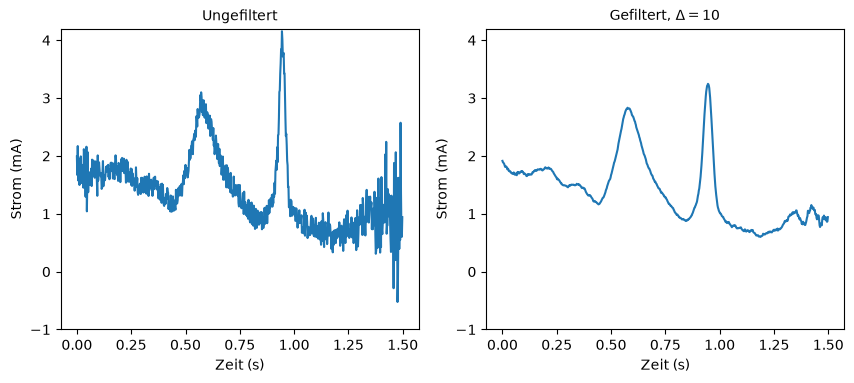

In [ ]:
data = np.loadtxt('Ex07/peaks.txt')
t = data[:, 0]
signal = data[:, 1]

# Glätten
delta = 10
filtered_signal = moving_average(signal, delta)

# Plotten
cm = 1 / 2.54

fig = plt.figure(figsize=(22 * cm, 10 * cm))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(t, signal, '-')
ax1.set_title('Ungefiltert', size=10)

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(t, filtered_signal, '-')
ax2.set_title('Gefiltert, $\\Delta = {}$'.format(delta), size=10)

for ax in (ax1, ax2):
    ax.set_xlabel('Zeit (s)')
    ax.set_ylabel('Strom (mA)')
    ax.set_ylim(-1, 4.2)

fig.tight_layout()

Das Glätten entfernt das schnelle Rauschen, während die langsameren Ausschläge beibehalten werden. Je grösser $\Delta$ gewählt wird, desto glatter wird das Signal. Die Peaks werden allerdings durch das Mitteln verbreitert, wenn $\Delta$ zu gross gewählt wird (probieren Sie z.B. $\Delta = 20$).

## c)

Bei welchen Frequenzen erwarten Sie eine Änderung in der spektralen Leistungsdichte, wenn Sie das gefilterte Signal betrachten?

Berechnen Sie mithilfe der Fouriertransformation die spektrale Leistungsdichte des Originalsignals und des geglätteten Signals. Bestätigt sich Ihre Vermutung? Welchen Einfluss hat der Wert $\Delta$?

Hinweis: Sie müssen die y-Achse logarithmisch plotten oder stark vergrössern, um den Effekt zu sehen. Das Spektrum wird ansonsten von den tiefen Frequenzen dominiert, da das Signal grösstenteils konstant ist.

### Lösung

Da das Glätten wie oben erwähnt das schnelle Rauschen entfernt, ist eine Unterdrückung der hohen Frequenzkomponenten zu erwarten.

Hier wird die Glättung noch einmal ausgerechnet, damit Sie mit dem Wert `delta` herumspielen können. Die x-Achse ist auf die positiven Frequenzen gezoomt und die y-Achse auf den relevanten Wertebereich.

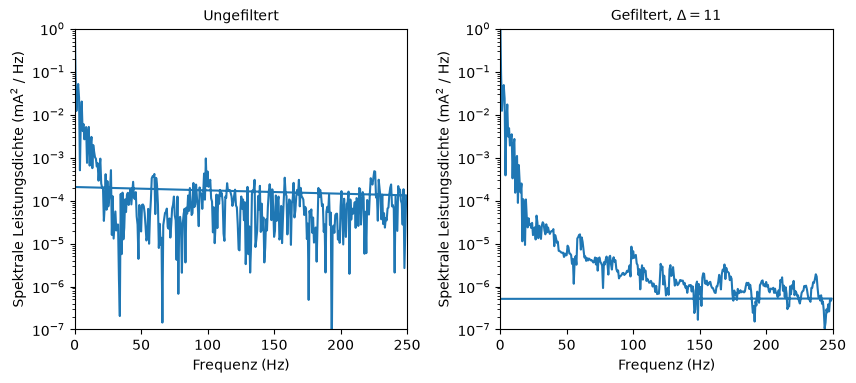

In [ ]:
N = len(signal)
dt = t[1] - t[0]

# Berechnen der Spectralen Leistungsdichte des orginal Signals
frequency = fftfreq(N, dt)
spectrum = fft(signal)
psd = dt / N * np.abs(spectrum)**2

# Berechnen der PSD des gefilterten Signals.
delta = 11

filtered_signal = moving_average(signal, delta)
filtered_spectrum = fft(filtered_signal)
filtered_psd = dt / N * np.abs(filtered_spectrum)**2

# Plotten
cm = 1 / 2.54

fig = plt.figure(figsize=(22 * cm, 10 * cm))

ax1 = fig.add_subplot(1, 2, 1)
ax1.semilogy(frequency, psd, '-')
ax1.set_title('Ungefiltert', size=10)

ax2 = fig.add_subplot(1, 2, 2)
ax2.semilogy(frequency, filtered_psd, '-')
ax2.set_title('Gefiltert, $\\Delta = {}$'.format(delta), size=10)

for ax in (ax1, ax2):
    ax.set_xlabel('Frequenz (Hz)')
    ax.set_ylabel('Spektrale Leistungsdichte (mA$^2$ / Hz)')
    ax.set_ylim(1e-7, 1)
    ax.set_xlim(0,  250)

fig.tight_layout()

Tatsächlich enfernt das Glätten die hohen Frequenzen aus dem Spektrum. Die Frequenzen, die gross genug sind, dass sie in dem Zeitbereich, über den gemittelt wird, mehrere Oszillationen haben, ergeben beim Mitteln Null, da sie etwa gleich oft positiv wie negativ ausschlagen. Dementsprechend ist ihr Beitrag im geglätteten Signal Null. Je höher die Frequenz, desto besser ist die Auslöschung der positiven und negativen Beiträge.

# Aufgabe 2: Filtern im Frequenzraum

In Aufgabe 1 haben Sie die Daten in der Zeitdomäne gefiltert und gesehen, wie sich das in der Frequenzdomäne wiederspiegelt. In dieser Aufgabe werden Sie die Daten in der Frequenzdomäne filtern und schauen, was der Effekt auf das zeitabhängige Signal ist.

## Hintergrund

In der Vorlesung haben Sie gesehen, dass man für die Bestimmung der Dauer eines kurzen Laserpulses dessen Autokovarianz oder Autokorrelation verwenden kann. Dies ist notwendig, weil Laserpulse viel kürzer (z.B. $150\,\mathrm{fs} = 150\cdot 10^{-15}\,\mathrm{s}$) sein können als die Abtastraten von Detektoren (bis zu GHz, also $\Delta t \sim 1\,\mathrm{ns} = 1\cdot 10^{-9}\,\mathrm{s}$).

In der Datei `data/exercise/autocorrelation_laser.txt` finden Sie eine Messung der Autokorrelation eines Laserpulses, die mit einem <a href=https://en.wikipedia.org/wiki/Michelson_interferometer>Michelson-Inteferometer</a> durchgeführt wurde. Das gemessene Signal hat die Einheit Volt und ist proportional zur Intensitätsautokorrelation des Laserlichts. Die Zeitachse entspricht der Zeitverzögerung zwischen den zwei Armen des Interferometers und damit der Zeitdifferenz zwischen den Laserpulsen, die miteinander interferieren.

## a)

Laden Sie den Datensatz `data/exercise/autocorrelation_laser.txt`, und berechnen Sie die Fouriertransformation des Signals. Plotten Sie dann sowohl das Signal als Funktion der Zeit, als auch die spektrale Leistungsdichte (mittels Wiener-Khinchin-Theorem).

### Lösung

In [6]:
data = np.loadtxt('Ex07/autocorrelation_laser.txt')
t = data[:, 0] * 1e-12  # in ps abgespeichert. Wir konvertieren in s
signal = data[:, 1]

## Um die PSD zu berechnen, müssen wir zuerst die Autokorrelation symmetrisieren:
pre_signal = signal[t<0]
post_signal = signal[t>0]
t_sym = t[t>0][:min(len(post_signal),len(pre_signal))]
symmetrized_signal = (np.flip(pre_signal[-min(len(post_signal),len(pre_signal)):]) + post_signal[:min(len(post_signal),len(pre_signal))])/2
# (x(-t) + x(t)) /2 das min kommt daher weil man die kleinere länge nimmt. Sonst fehler
# Zeitauflösung und Länge des Signals berechnen
dt = t[1] - t[0]
N = len(t_sym)

# Spektrale Leistungsdichte
psd = fft(symmetrized_signal)
frequency = fftfreq(N, d=dt)

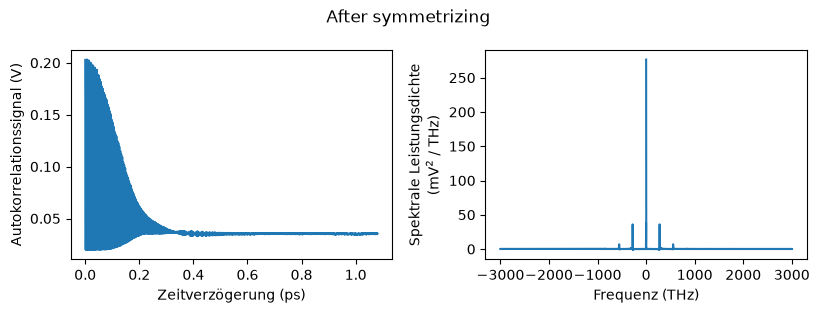

In [ ]:
cm = 1 / 2.54

fig = plt.figure(figsize=(21 * cm, 8 * cm))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(t_sym * 1e12, symmetrized_signal, '-')
ax1.set_xlabel('Zeitverzögerung (ps)')
ax1.set_ylabel('Autokorrelationssignal (V)')

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(frequency / 1e12, psd, '-')
ax2.set_xlabel('Frequenz (THz)')
ax2.set_ylabel('Spektrale Leistungsdichte\n(mV$^2$ / THz)')
# ax2.set_yscale('log')
fig.suptitle("After symmetrizing")
fig.tight_layout()

Da das Signal immer positiv ist, sieht man im Spektrum einen dominanten Peak bei der Frequenz $f = 0$. Dieser Peak entspricht einem konstanten Offset und ist bei realen Messdaten in den meisten Fällen vorhanden.

Durch Vergrössern erkennt man im zeitabhängigen Signal die schnelle Oszillation innerhalb der Einhüllenden des Pulses. Im Spektrum wird durch logarithmisches Plotten die dominante endliche Frequenzkomponente bei $f \approx 280$ THz sichtbar, sowie deren höhere Harmonische, die allerdings um Grössenordnungen kleiner sind.

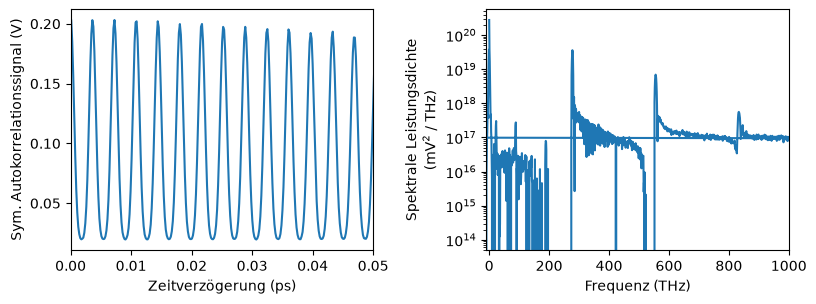

In [ ]:
cm = 1 / 2.54

fig = plt.figure(figsize=(21 * cm, 8 * cm))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(t_sym * 1e12, symmetrized_signal, '-')
ax1.set_xlabel('Zeitverzögerung (ps)')
ax1.set_ylabel('Sym. Autokorrelationssignal (V)')

ax1.set_xlim(0, 0.05)


ax2 = fig.add_subplot(1, 2, 2)
ax2.semilogy(frequency / 1e12, psd * 1e12 * 1e6, '-')
ax2.set_xlabel('Frequenz (THz)')
ax2.set_ylabel('Spektrale Leistungsdichte\n(mV$^2$ / THz)')

ax2.set_xlim(-10, 1000)
# ax2.set_ylim(0, 100)

fig.tight_layout()

## b)

Berechnen Sie mit `np.fft.ifft` die Fourier-Rücktransformation, und plotten Sie diese als Funktion der Zeit, um sich zu vergewissern, dass Sie das ursprüngliche Signal rekonstruieren können.

### Lösung

Text(0, 0.5, 'Rekonstruiertes Signal U(t) (V)')

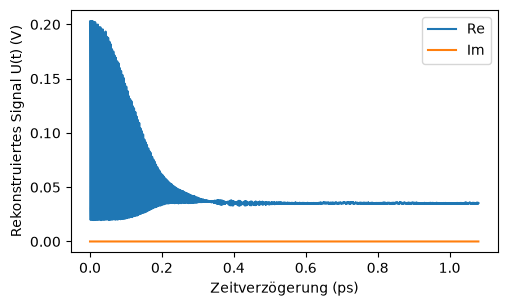

In [ ]:
signal_reconstruct = ifft(psd)

cm = 1 / 2.54
fig = plt.figure(figsize=(14 * cm, 8 * cm))

ax1 = fig.add_subplot(1, 1, 1)
# Wir plotten Realteil und Imaginärteil des rekonstruierten Signals, um zu überprüfen,
# dass das Signal rein reell ist.
ax1.plot(t_sym * 1e12, np.real(signal_reconstruct), '-', label='Re')
ax1.plot(t_sym * 1e12, np.imag(signal_reconstruct), '-', label='Im')
ax1.legend()
ax1.set_xlabel('Zeitverzögerung (ps)')
ax1.set_ylabel('Rekonstruiertes Signal U(t) (V)')

## c)

Schreiben Sie nun eine Funktion, die ein Signal im Frequenzraum filtert und das gefilterte Signal zurückgibt. Die Funktion soll als Argumente ein zeitabhängiges Signal nehmen (Zeitachse $t$, Messwerte $s(t)$), sowie die untere Grenze $f_{\mathrm{min}}$ und obere Grenze $f_{\mathrm{max}}$ eines Frequenzbereichs. Berechnen Sie die Fouriertransformation des Signals, und setzen Sie dann alle Frequenzen ausserhalb des Frequenzbereichs $[f_{\mathrm{min}}, f_{\mathrm{max}}]$ auf Null. Das gefilterte Signal erhalten Sie aus der Rücktransformation des modifizierten Spektrums.

Hinweis: Beachten Sie, dass auch negative Frequenzen vorkommen. Daher müssen Sie beim Filtern alle Frequenzen $f_n$ behalten, die 

$$ f_{\mathrm{min}} \leq \left| f_n \right| \leq f_{\mathrm{max}} $$

erfüllen.

### Lösung

In [ ]:
def filter_signal(t, signal, f_min, f_max):
    '''Filter a signal by keeping only Fourier components between f_min and f_max.'''
    # Zeitauflösung und Anzahl Punkte im Signal
    dt = t[1] - t[0]
    N = len(t)
    
    # Fouriertransformation
    frequency = fftfreq(N, d=dt)
    spectrum = fft(signal)
    


    # In einer for-Schleife werden alle Frequenzen durchlaufen. Wenn die Frequenz
    # ausserhalb des gewählten Bereichs liegt, wird die entsprechende Amplitude
    # auf Null gesetzt.
    for i in range(len(frequency)):
        if abs(frequency[i]) < f_min or f_max < abs(frequency[i]):
            spectrum[i] = 0
    
    # Rücktransformation des gefilterten Spektrums. Der Imaginärteil ist Null und kann
    # verworfen werden.
    filtered_signal = np.real(ifft(spectrum))
    return filtered_signal

## d)

Verwenden Sie Ihre Funktion aus c), um auf das Signal, das Sie in a) geladen haben, einen Tiefpassfilter anzuwenden (d.h. hohe Frequenzen über einem Grenzwert werden herausgefiltert). Plotten Sie das gefilterte Signal als Funktion der Zeit.

Was passiert, wenn Sie statt einem Tiefpassfilter einen Hochpassfilter anwenden (also Frequenzen unter dem Grenzwert herausfiltern)? Welches Signal würden Sie verwenden, um die Länge des Laserpulses zu bestimmen?

Hinweis: Wählen Sie den Grenzwert kleiner als die erste endliche Frequenzkomponente des Signals, so dass die oszillierenden und die nicht oszillierenden Teile des Signals getrennt werden.

### Lösung

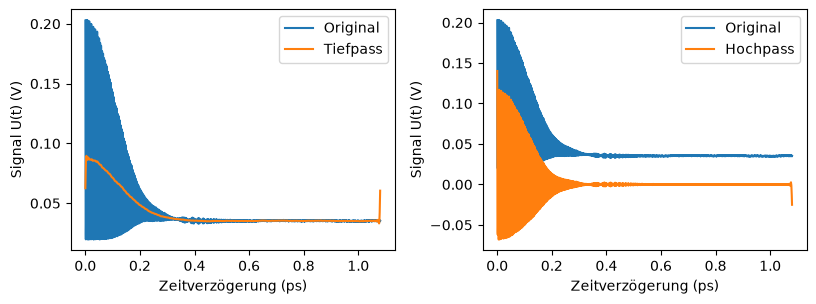

In [ ]:
cutoff = 150e12
f_ny = 1 / (2 * (t[1] - t[0]))

filtered_lowpass = filter_signal(t_sym, symmetrized_signal, 0, cutoff)
filtered_highpass = filter_signal(t_sym, symmetrized_signal, cutoff, f_ny)

cm = 1 / 2.54
fig = plt.figure(figsize=(21 * cm, 8 * cm))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(t_sym * 1e12, symmetrized_signal, '-', label='Original')
ax1.plot(t_sym * 1e12, filtered_lowpass, '-', label='Tiefpass')
ax1.legend()
ax1.set_xlabel('Zeitverzögerung (ps)')
ax1.set_ylabel('Signal U(t) (V)')

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(t_sym * 1e12, symmetrized_signal, '-', label='Original')
ax2.plot(t_sym * 1e12, filtered_highpass, '-', label='Hochpass')
ax2.legend()
ax2.set_xlabel('Zeitverzögerung (ps)')
ax2.set_ylabel('Signal U(t) (V)')
fig.tight_layout()

Um die zwei Frequenzkomponenten des Signals zu trennen, kann für den Filter irgendein Grenzwert zwischen ca. 5 THz und 270 THz gewählt werden. Mit dem Tiefpassfilter kann man die Einhüllende des Pulses extrahieren (bis auf einen Skalierungsfaktor). Diese kann dann weiter analysiert werden, um die Pulslänge zu bestimmen. Zum Beispiel kann sie mit einer Gaussfunktion angenähert werden, oder die Breite auf halber Höhe kann numerisch ermittelt werden.

## e)

Laden Sie nun den Datensatz `data/exercise/noisy_pulse.txt`, und plotten Sie wieder das Signal als Funktion der Zeit und die spektrale Leistungsdichte. Lesen Sie aus dem Spektrum die dominante Frequenzkomponente ab, und verwenden Sie Ihre Funktion aus c), um einen Bandpassfilter in diesem Frequenzbereich auf die Daten anzuwenden; d.h. Sie behalten nur die Frequenzen aus einem kleinen Bereich rund um die dominante Frequenzkomponente.

Hinweis: Sie sollten nach Anwenden des Filters eine Oszillation mit einer gaussförmigen Einhüllenden bekommen.

### Lösung

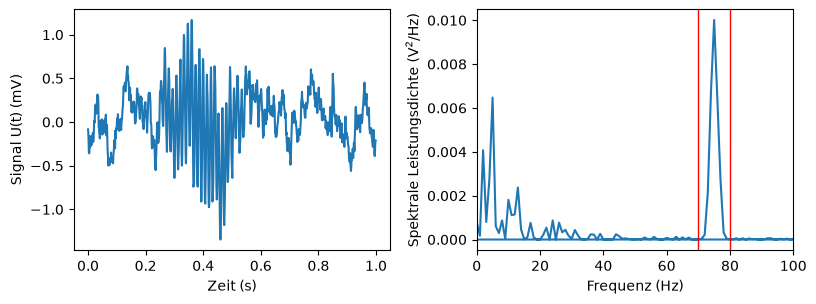

In [7]:
# Daten laden
data = np.loadtxt('Ex07/noisy_pulse.txt')
t = data[:, 0]
signal = data[:, 1]

# Fouriertransformation und spektrale Leistungsdichte
N = len(t)
dt = t[1] - t[0]

frequency = fftfreq(N, dt)
spectrum = fft(signal)
psd = dt / N * np.abs(spectrum)**2


# Daten Plotten
cm = 1 / 2.54

fig = plt.figure(figsize=(21 * cm, 8 * cm))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(t, signal, '-')
ax1.set_xlabel('Zeit (s)')
ax1.set_ylabel('Signal U(t) (mV)')

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(frequency, psd, '-')
ax2.set_xlabel('Frequenz (Hz)')
ax2.set_ylabel('Spektrale Leistungsdichte (V$^2$/Hz)')
ax2.set_xlim(0, 100)

ax2.axvline(70, color='r', linewidth=1)
ax2.axvline(80, color='r', linewidth=1)

fig.tight_layout()

Man sieht im originalen Signal, dass zwischen 0.3 s und 0.6 s etwas passiert, allerdings ist das Rauschen relativ gross. Die dominante Signalfrequenz ist zwischen 70 Hz und 80 Hz, während das Rauschen vor allem bei niedrigen Frequenzen gross ist. Dass die niedrigen Frequenzen nur Rauschen enthalten, können Sie auch mit einem Tiefpassfilter überprüfen.

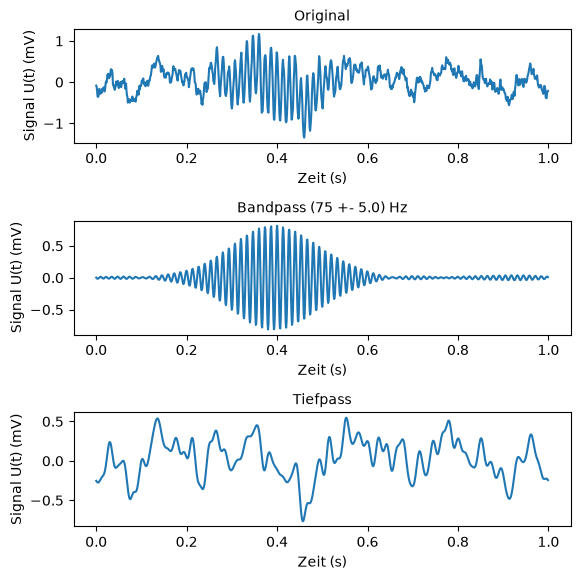

In [ ]:
center = 75
width = 10
bandpass_signal = filter_signal(t, signal, center - width / 2, center + width / 2)
lowpass_signal = filter_signal(t, signal, 0, 60)

cm = 1 / 2.54

fig = plt.figure(figsize=(15 * cm, 15 * cm))

ax1 = fig.add_subplot(3, 1, 1)
ax1.plot(t, signal, '-')
ax1.set_xlabel('Zeit (s)')
ax1.set_ylabel('Signal U(t) (mV)')
ax1.set_title('Original', size=10)

ax2 = fig.add_subplot(3, 1, 2)
ax2.plot(t, bandpass_signal, '-')
ax2.set_xlabel('Zeit (s)')
ax2.set_ylabel('Signal U(t) (mV)')
ax2.set_title('Bandpass ({} +- {}) Hz'.format(center, width/2), size=10)

ax3 = fig.add_subplot(3, 1, 3)
ax3.plot(t, lowpass_signal, '-')
ax3.set_xlabel('Zeit (s)')
ax3.set_ylabel('Signal U(t) (mV)')
ax3.set_title('Tiefpass', size=10)

fig.tight_layout()

Man sieht, dass die schnelle Oszillation von einem Puls bei 0.4 s kommt. Nach Anwenden des Bandpassfilters ist die Form des Pulses wieder erkennbar, und man könnte z.B. wieder dessen Länge bestimmen.

# Nachbemerkung

Bei all diesen Aufgaben war immer von einem zeitabhängigen Signal die Rede, so dass das Spektrum auch echten Frequenzen entspricht. Allerdings ist dies nicht nötig, um diese Methoden anzuwenden; sie funktionieren für jedes Array von Datenpunkten, unabhängig davon, was die x-Achse dazu ist. Tatsächlich waren die Daten aus Aufgabe 1 nicht ein zeitabhängiges Signal, sondern ein optisches Reflexionsspektrum und die x-Achse entspricht in Wirklichkeit einer Wellenlänge. Dennoch kann man die Daten durch Mitteln oder Tiefpassfiltern im Fourier-Raum glätten.